# DATASET ADULTS

In [74]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
matplotlib.__version__

'3.10.0'

## CARGA DEL DATASET (ya "limpio" en adult_final.csv)

In [75]:
RUTA = 'https://raw.githubusercontent.com/SonikoKatsura/CURSO_PARO_IA/refs/heads/main/Rober_IA/Modulo2/datos/adult_final.csv'

df_adult = pd.read_csv(RUTA)

df_adult.sample(n=10)


,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,income,capital_dif
20796,29,Private,Bachelors,Never-married,Prof-specialty,Own-child,Asian-Pac-Islander,Male,64,Philippines,1,0
22041,58,Self-emp-not-inc,Bachelors,Divorced,Prof-specialty,Not-in-family,White,Female,40,United-States,0,0
7629,49,Private,7th-8th,Married-civ-spouse,Craft-repair,Husband,White,Male,40,United-States,0,0
11590,50,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,50,United-States,1,15024
16747,22,Private,Some-college,Never-married,Adm-clerical,Own-child,White,Female,15,United-States,0,0
3645,58,Private,HS-grad,Divorced,Machine-op-inspct,Not-in-family,White,Male,30,United-States,0,3325
9241,37,Local-gov,Some-college,Married-civ-spouse,Adm-clerical,Husband,White,Male,40,Canada,1,0
16842,46,Local-gov,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,38,United-States,1,0
24472,63,Private,Some-college,Widowed,Adm-clerical,Unmarried,White,Female,43,United-States,0,0
14485,51,Private,9th,Never-married,Other-service,Unmarried,Black,Female,40,United-States,0,0


In [76]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29096 entries, 0 to 29095
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             29096 non-null  int64 
 1   workclass       27464 non-null  object
 2   education       29096 non-null  object
 3   marital_status  29096 non-null  object
 4   occupation      27457 non-null  object
 5   relationship    29096 non-null  object
 6   race            29096 non-null  object
 7   sex             29096 non-null  object
 8   hours_per_week  29096 non-null  int64 
 9   native_country  28516 non-null  object
 10  income          29096 non-null  int64 
 11  capital_dif     29096 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 2.7+ MB


In [77]:
# variables numericas
df_adult.describe()


,age,hours_per_week,income,capital_dif
count,29096.000000,29096.000000,29096.000000,29096.000000
mean,39.251340,40.637820,0.247800,1100.627028
std,13.687157,12.735418,0.431743,7804.701906
min,17.000000,1.000000,0.000000,-4356.000000
25%,28.000000,40.000000,0.000000,0.000000
50%,38.000000,40.000000,0.000000,0.000000
75%,48.000000,45.000000,0.000000,0.000000
max,90.000000,99.000000,1.000000,99999.000000


In [78]:
# variables categoricas
df_adult.describe(include=['object'])

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
count,27464,29096,29096,27457,29096,29096,29096,28516
unique,8,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,19621,8886,13249,3885,11506,24438,19246,25721


### Algunos cambios previos

**NOTA: cambiar el orden de las columnas para ordenarlas (mínimo que la última columna sea target)**

In [79]:
df_adult.columns

Index(['age', 'workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'hours_per_week', 'native_country',
       'income', 'capital_dif'],
      dtype='object')

**Aprovechamos y nos quitamos de encima las columnas 'fnlwgt' y 'education_num':**

In [80]:
df_adult = df_adult[['age', 'sex', 'marital_status', 'relationship', 'race', 'native_country', 'education', 'workclass', 'occupation',
                    'hours_per_week',  'capital_dif', 'income']]

In [81]:
df_adult.head()

,age,sex,marital_status,relationship,race,native_country,education,workclass,occupation,hours_per_week,capital_dif,income
0,39,Male,Never-married,Not-in-family,White,United-States,Bachelors,State-gov,Adm-clerical,40,2174,0
1,50,Male,Married-civ-spouse,Husband,White,United-States,Bachelors,Self-emp-not-inc,Exec-managerial,13,0,0
2,38,Male,Divorced,Not-in-family,White,United-States,HS-grad,Private,Handlers-cleaners,40,0,0
3,53,Male,Married-civ-spouse,Husband,Black,United-States,11th,Private,Handlers-cleaners,40,0,0
4,28,Female,Married-civ-spouse,Wife,Black,Cuba,Bachelors,Private,Prof-specialty,40,0,0


# ANÁLISIS UNIDIMENSIONAL

Separamos variables por tipo:

In [82]:
variables_numericas = df_adult.select_dtypes(exclude=['object']).columns.to_list()

variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

In [83]:
variables_categoricas = df_adult.select_dtypes(include=['object']).columns.to_list()

variables_categoricas

['sex',
 'marital_status',
 'relationship',
 'race',
 'native_country',
 'education',
 'workclass',
 'occupation']

In [84]:
target = 'income'

## NUMERICAS: histograma y función de densidad

### Primer acercamiento

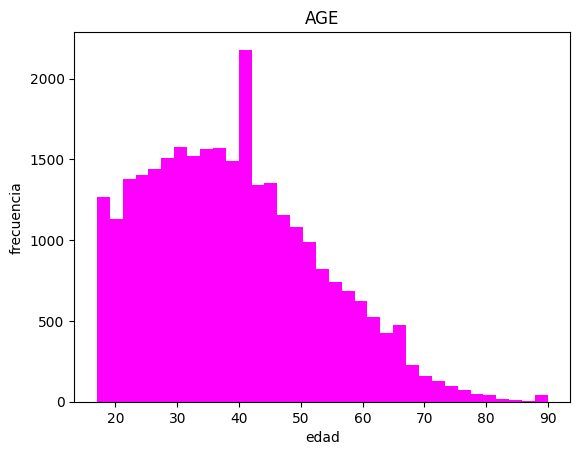

In [85]:
plt.hist(df_adult.age, bins=35, color='magenta')
plt.title('AGE')
plt.xlabel('edad')
plt.ylabel('frecuencia');

### Una sola gráfica con SUBPLOTS

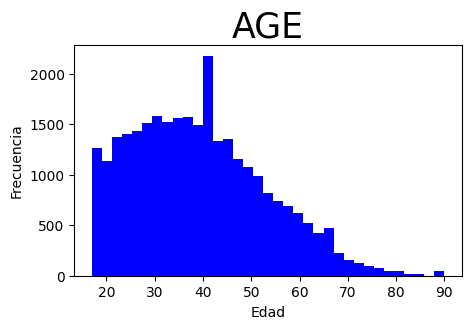

In [86]:
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_adult.age, bins=35, color='blue')

ax.set_title('AGE', fontsize=25)
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia');



In [87]:
variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

### EJERCICIO 1.

Haz el resto de gráficas, excepto la de 'income'

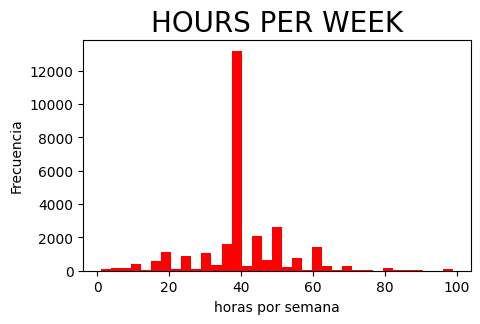

In [88]:
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_adult.hours_per_week, bins=35, color='red')

ax.set_title('HOURS PER WEEK', fontsize=20)
ax.set_xlabel('horas por semana')
ax.set_ylabel('Frecuencia');


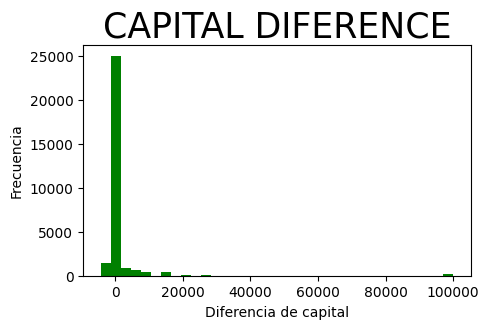

In [89]:
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_adult.capital_dif, bins=35, color='green')

ax.set_title('CAPITAL DIFERENCE', fontsize=25)
ax.set_xlabel('Diferencia de capital')
ax.set_ylabel('Frecuencia');


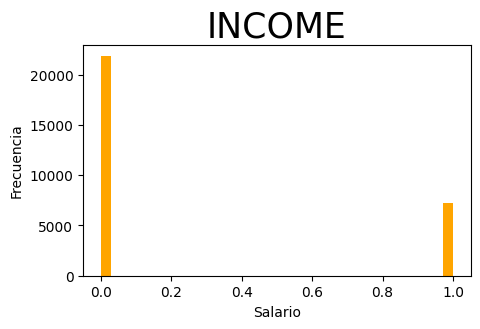

In [90]:
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_adult.income, bins=35, color='orange')

ax.set_title('INCOME', fontsize=25)
ax.set_xlabel('Salario')
ax.set_ylabel('Frecuencia');

### - Agrupar gráficas (subplots)

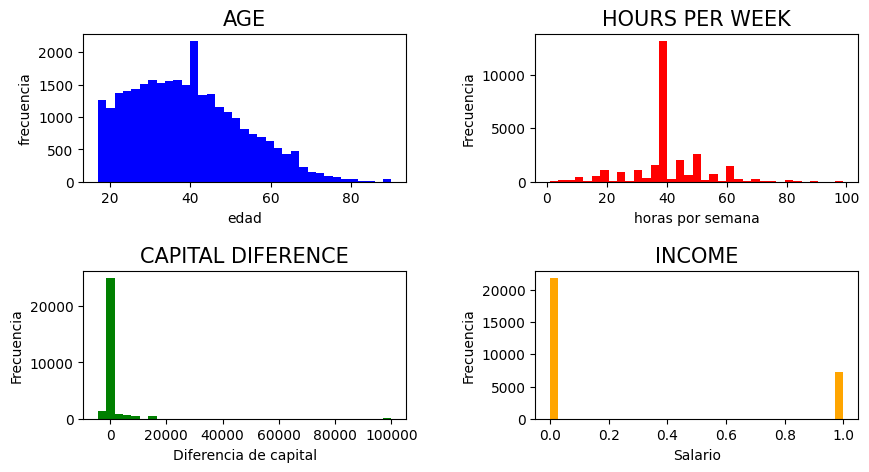

In [91]:
fig, ax = plt.subplots(2,2,figsize=(10,5), gridspec_kw={'hspace': 0.6, 'wspace': 0.4})

ax[0,0].hist(df_adult.age, bins=35, color='blue')

ax[0,0].set_title('AGE', fontsize=15)
ax[0,0].set_xlabel('edad')
ax[0,0].set_ylabel('frecuencia');

ax[0,1].hist(df_adult.hours_per_week, bins=35, color='red')

ax[0,1].set_title('HOURS PER WEEK', fontsize=15)
ax[0,1].set_xlabel('horas por semana')
ax[0,1].set_ylabel('Frecuencia');

ax[1,0].hist(df_adult.capital_dif, bins=35, color='green')

ax[1,0].set_title('CAPITAL DIFERENCE', fontsize=15)
ax[1,0].set_xlabel('Diferencia de capital')
ax[1,0].set_ylabel('Frecuencia');

ax[1,1].hist(df_adult.income, bins=35, color='orange')

ax[1,1].set_title('INCOME', fontsize=15)
ax[1,1].set_xlabel('Salario')
ax[1,1].set_ylabel('Frecuencia');

**Pregunta: ¿qué sentido tiene la indexación de ejes? (los números entre corchetes)**

*   ***Se refiere a la posicion en la tabla según los subplots que hemos creado.***




In [92]:
variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

### EJERCICIO 2.

Haz el resto de gráficas, excepto la de 'income', pero presentalas primero horizontalmente (izda-drcha) y luego verticalmente (arriba-abajo). Sugerencia: de las etiquetas solo es necesaria el título

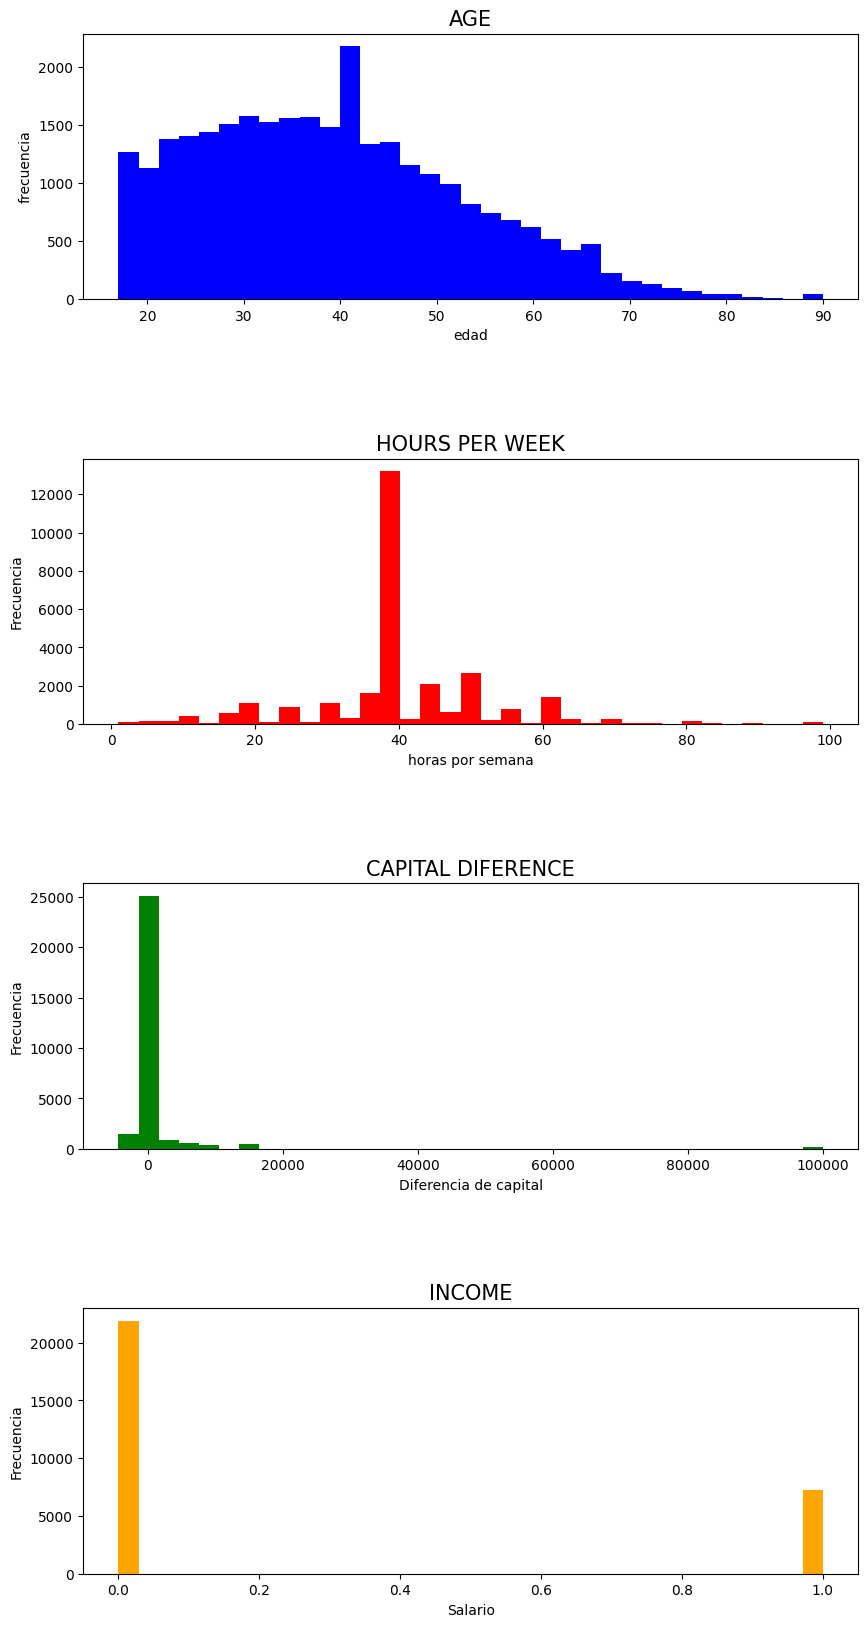

In [93]:
fig, ax = plt.subplots(4,1,figsize=(10,20), gridspec_kw={'hspace': 0.6, 'wspace': 0.4})

ax[0].hist(df_adult.age, bins=35, color='blue')

ax[0].set_title('AGE', fontsize=15)
ax[0].set_xlabel('edad')
ax[0].set_ylabel('frecuencia');

ax[1].hist(df_adult.hours_per_week, bins=35, color='red')

ax[1].set_title('HOURS PER WEEK', fontsize=15)
ax[1].set_xlabel('horas por semana')
ax[1].set_ylabel('Frecuencia');

ax[2].hist(df_adult.capital_dif, bins=35, color='green')

ax[2].set_title('CAPITAL DIFERENCE', fontsize=15)
ax[2].set_xlabel('Diferencia de capital')
ax[2].set_ylabel('Frecuencia');

ax[3].hist(df_adult.income, bins=35, color='orange')

ax[3].set_title('INCOME', fontsize=15)
ax[3].set_xlabel('Salario')
ax[3].set_ylabel('Frecuencia');

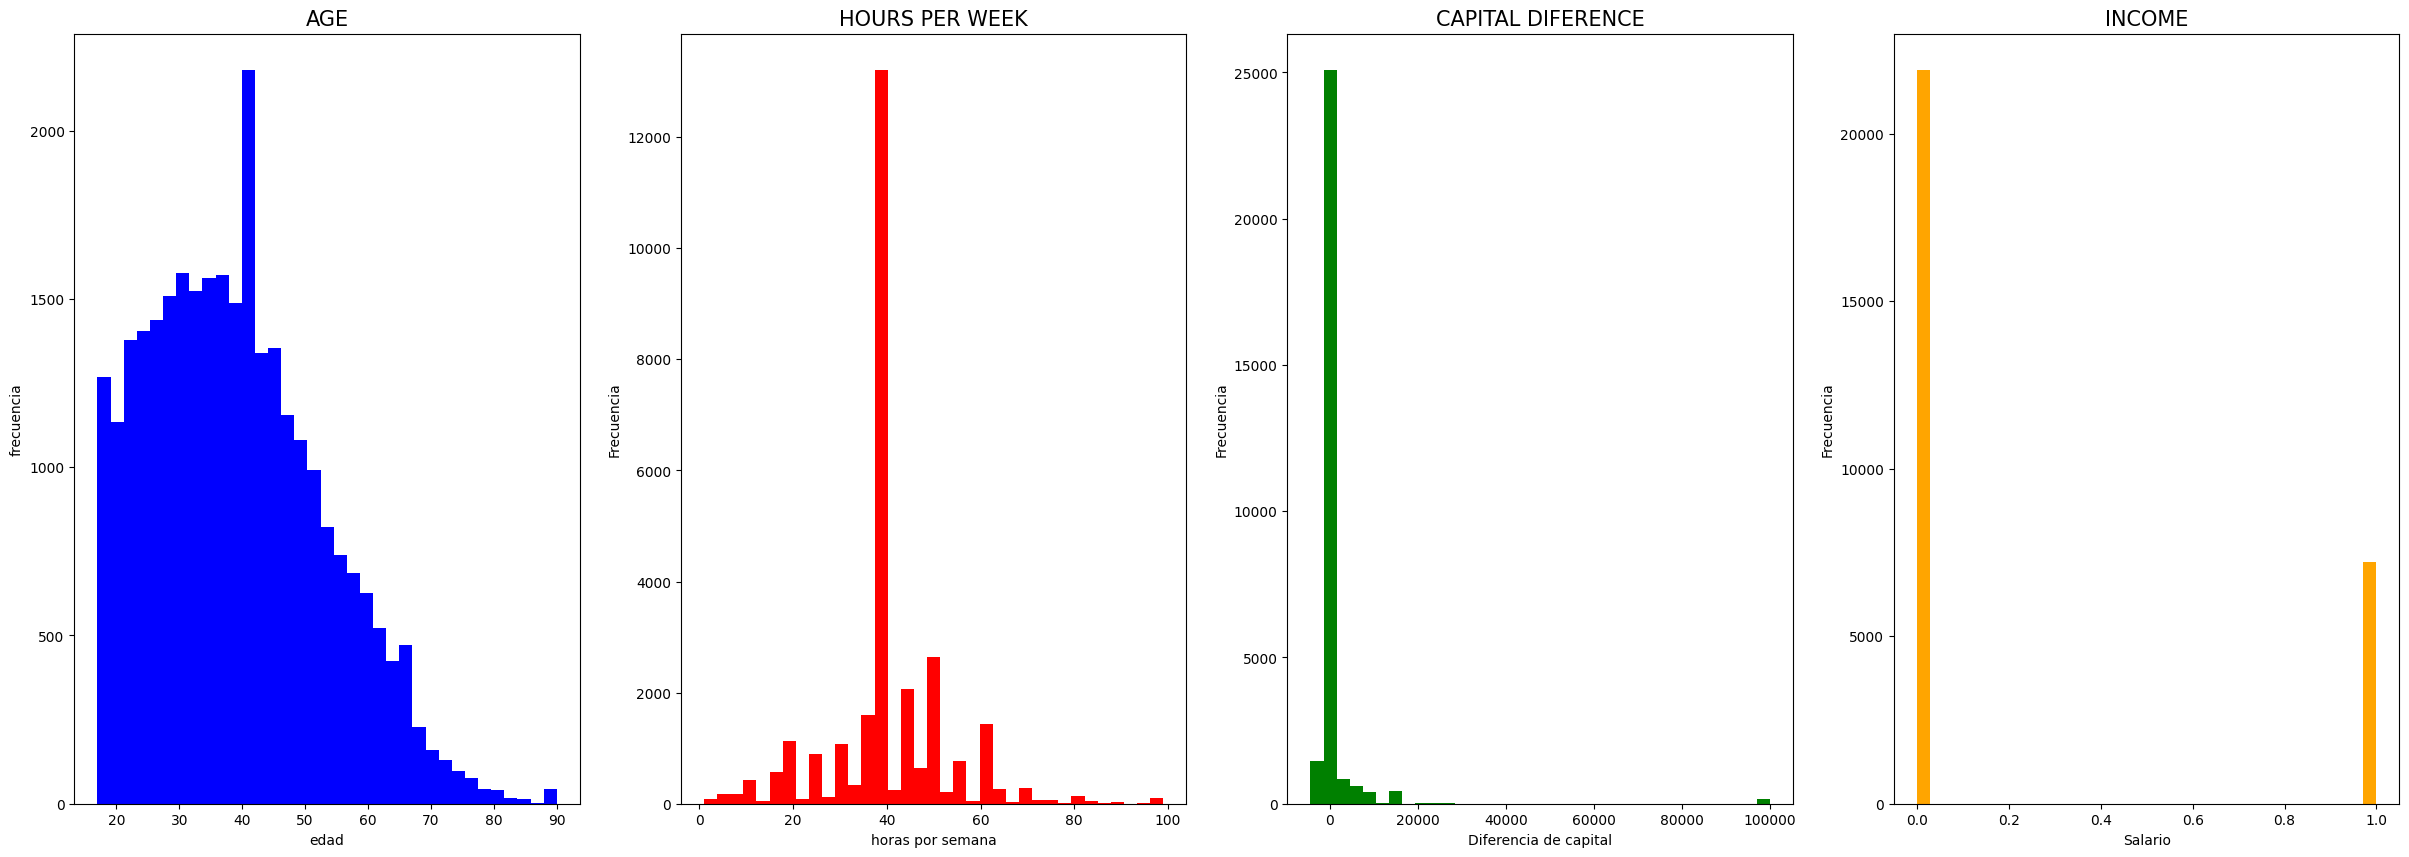

In [94]:
fig, ax = plt.subplots(1,4,figsize=(30,10), gridspec_kw={'hspace': 0.4, 'wspace': 0.2})

ax[0].hist(df_adult.age, bins=35, color='blue')

ax[0].set_title('AGE', fontsize=15)
ax[0].set_xlabel('edad')
ax[0].set_ylabel('frecuencia');

ax[1].hist(df_adult.hours_per_week, bins=35, color='red')

ax[1].set_title('HOURS PER WEEK', fontsize=15)
ax[1].set_xlabel('horas por semana')
ax[1].set_ylabel('Frecuencia');

ax[2].hist(df_adult.capital_dif, bins=35, color='green')

ax[2].set_title('CAPITAL DIFERENCE', fontsize=15)
ax[2].set_xlabel('Diferencia de capital')
ax[2].set_ylabel('Frecuencia');

ax[3].hist(df_adult.income, bins=35, color='orange')

ax[3].set_title('INCOME', fontsize=15)
ax[3].set_xlabel('Salario')
ax[3].set_ylabel('Frecuencia');

### - Uso de  libreria "Seaborn" + Agrupar gráficas (subplots)

Primero uno solo:

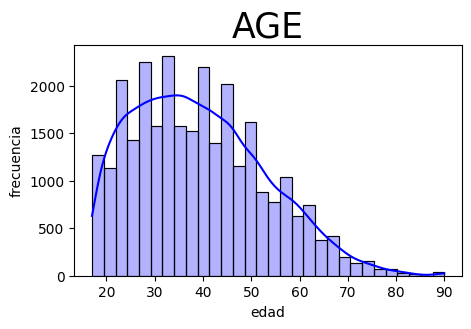

In [95]:
fig, mi_ax = plt.subplots(figsize=(5,3))

sns.histplot(df_adult.age, bins=30, ax=mi_ax, color='blue', kde=True, alpha=.3)

mi_ax.set_title('AGE', fontsize=25)
mi_ax.set_xlabel('edad')
mi_ax.set_ylabel('frecuencia');

Con varias graficas solo hay que pasar el eje al método de seaborn:


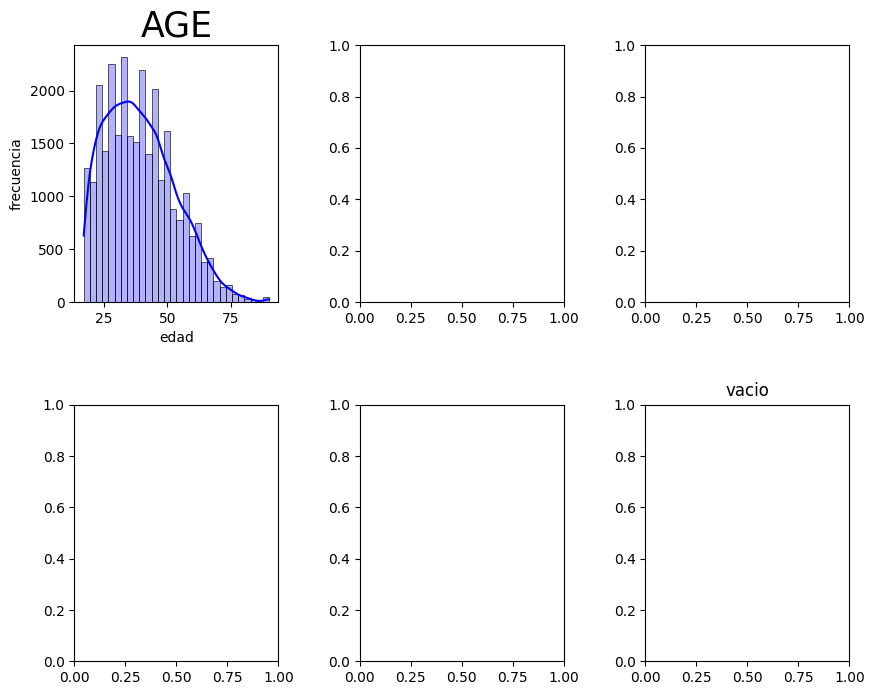

In [96]:
fig, ax = plt.subplots(2,3,figsize=(10,8), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.histplot(df_adult.age, bins=30, ax=ax[0,0], color='blue', kde=True, alpha=.3)
ax[0,0].set_title('AGE', fontsize=25)
ax[0,0].set_xlabel('edad')
ax[0,0].set_ylabel('frecuencia')

ax[1,2].set_title('vacio');

### EJERCICIO 3.

Haz de nuevo el EJERCICIO 2, pero esta vez utilizando la librería SEABORN

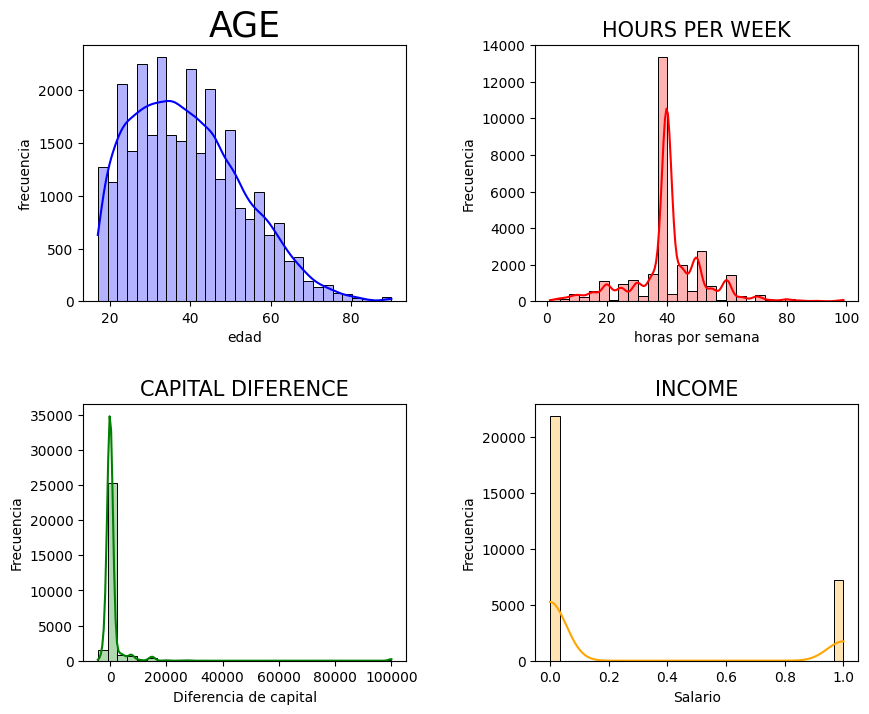

In [97]:
fig, ax = plt.subplots(2,2,figsize=(10,8), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.histplot(df_adult.age, bins=30, ax=ax[0,0], color='blue', kde=True, alpha=.3)

ax[0,0].set_title('AGE', fontsize=25)
ax[0,0].set_xlabel('edad')
ax[0,0].set_ylabel('frecuencia')

sns.histplot(df_adult.hours_per_week, bins=30, ax=ax[0,1],color='red', kde=True, alpha=.3)

ax[0,1].set_title('HOURS PER WEEK', fontsize=15)
ax[0,1].set_xlabel('horas por semana')
ax[0,1].set_ylabel('Frecuencia');

sns.histplot(df_adult.capital_dif, bins=30, ax=ax[1,0],color='green', kde=True, alpha=.3)

ax[1,0].set_title('CAPITAL DIFERENCE', fontsize=15)
ax[1,0].set_xlabel('Diferencia de capital')
ax[1,0].set_ylabel('Frecuencia');

sns.histplot(df_adult.income, bins=30, ax=ax[1,1], color='orange', kde=True, alpha=.3)

ax[1,1].set_title('INCOME', fontsize=15)
ax[1,1].set_xlabel('Salario')
ax[1,1].set_ylabel('Frecuencia');

In [98]:
variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

### - Ultima vuelta de tuerca: varias representaciones en la misma gráfica:

<ipython-input-99-2a65883625a7>:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  mi_ax.legend();


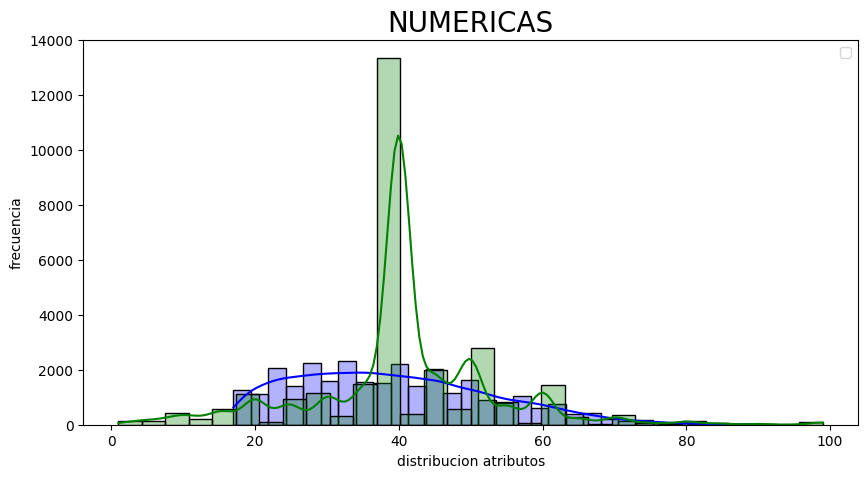

In [99]:
fig, mi_ax = plt.subplots(figsize=(10,5))

sns.histplot(df_adult.age, bins=30, ax=mi_ax, color='blue', kde=True, alpha=.3)
sns.histplot(df_adult.hours_per_week, bins=30, ax=mi_ax, color='green', kde=True, alpha=.3)

mi_ax.set_title('NUMERICAS', fontsize=20)
mi_ax.set_xlabel('distribucion atributos')
mi_ax.set_ylabel('frecuencia')
mi_ax.legend();


## NUMERICAS: diagrama de cajas

### - Uso de "boxplot"

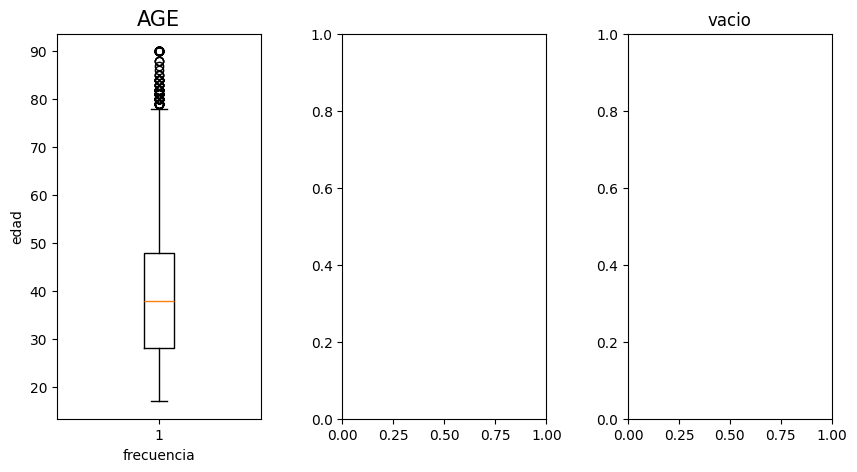

In [100]:
fig, mi_ax = plt.subplots(1,3,figsize=(10,5), gridspec_kw={'hspace': 0.4, 'wspace': 0.4},)

mi_ax[0].boxplot(df_adult.age)

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_xlabel('frecuencia')
mi_ax[0].set_ylabel('edad')

mi_ax[2].set_title('vacio');

### EJERCICIO 4.

Haz el resto de gráficas, excepto la de 'income', horizontalmente (izda-drcha) y verticalmente. Para esta última busca en la doc "matplotlib boxplot" cómo actúa el parámetro "vert". Sugerencia: de las etiquetas solo es necesaria el título

Text(0.5, 0, 'Frecuencia')

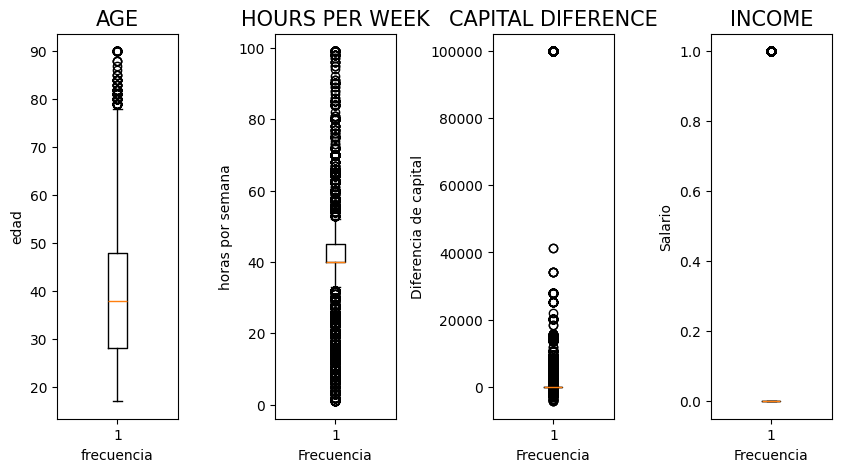

In [101]:
fig, mi_ax = plt.subplots(1,4,figsize=(10,5), gridspec_kw={'hspace': 0.4, 'wspace': 0.8},)

mi_ax[0].boxplot(df_adult.age, orientation='vertical')

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_ylabel('edad')
mi_ax[0].set_xlabel('frecuencia')

mi_ax[1].boxplot(df_adult.hours_per_week, orientation='vertical')

mi_ax[1].set_title('HOURS PER WEEK', fontsize=15)
mi_ax[1].set_ylabel('horas por semana')
mi_ax[1].set_xlabel('Frecuencia');

mi_ax[2].boxplot(df_adult.capital_dif, orientation='vertical')

mi_ax[2].set_title('CAPITAL DIFERENCE', fontsize=15)
mi_ax[2].set_ylabel('Diferencia de capital')
mi_ax[2].set_xlabel('Frecuencia');

mi_ax[3].boxplot(df_adult.income, orientation='vertical')

mi_ax[3].set_title('INCOME', fontsize=15)
mi_ax[3].set_ylabel('Salario')
mi_ax[3].set_xlabel('Frecuencia')

Text(0, 0.5, 'Frecuencia')

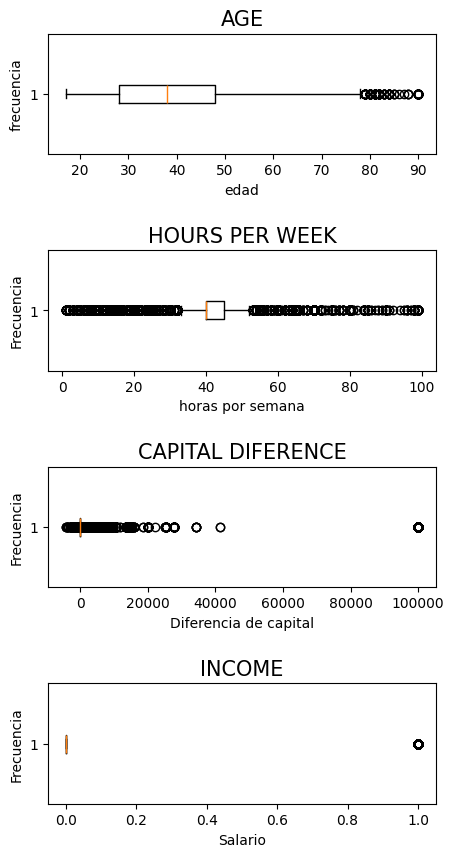

In [102]:
fig, mi_ax = plt.subplots(4,1,figsize=(5,10), gridspec_kw={'hspace': 0.8, 'wspace': 0.4},)

mi_ax[0].boxplot(df_adult.age, orientation='horizontal')

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_xlabel('edad')
mi_ax[0].set_ylabel('frecuencia')

mi_ax[1].boxplot(df_adult.hours_per_week, orientation='horizontal')

mi_ax[1].set_title('HOURS PER WEEK', fontsize=15)
mi_ax[1].set_xlabel('horas por semana')
mi_ax[1].set_ylabel('Frecuencia');

mi_ax[2].boxplot(df_adult.capital_dif, orientation='horizontal')

mi_ax[2].set_title('CAPITAL DIFERENCE', fontsize=15)
mi_ax[2].set_xlabel('Diferencia de capital')
mi_ax[2].set_ylabel('Frecuencia');

mi_ax[3].boxplot(df_adult.income, orientation='horizontal')

mi_ax[3].set_title('INCOME', fontsize=15)
mi_ax[3].set_xlabel('Salario')
mi_ax[3].set_ylabel('Frecuencia')

### - Uso de  libreria "Seaborn"

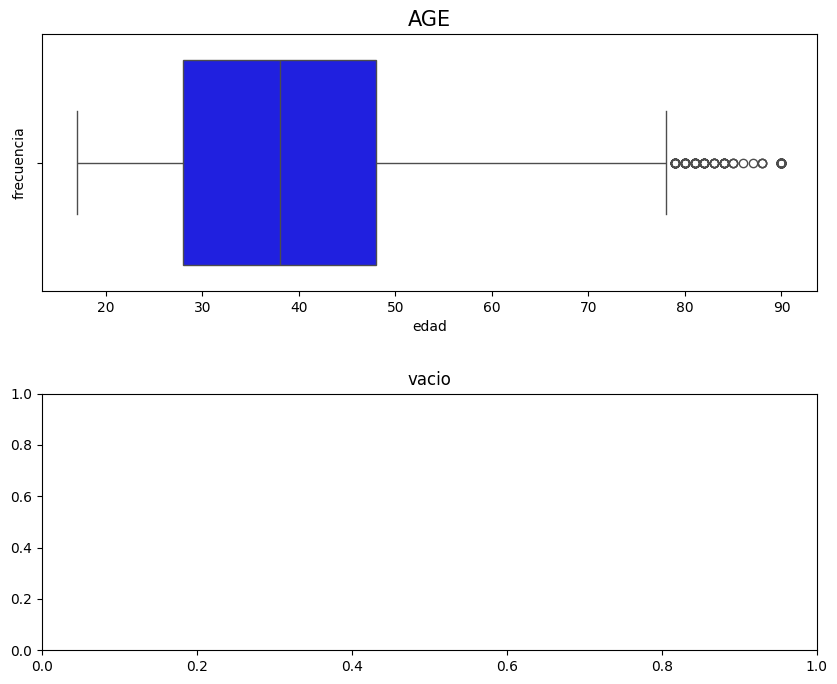

In [103]:
fig, mi_ax = plt.subplots(2,1,figsize=(10,8), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.boxplot(x='age', data=df_adult, ax=mi_ax[0], color='blue')

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_xlabel('edad')
mi_ax[0].set_ylabel('frecuencia')

mi_ax[1].set_title('vacio');

<Axes: xlabel='age'>

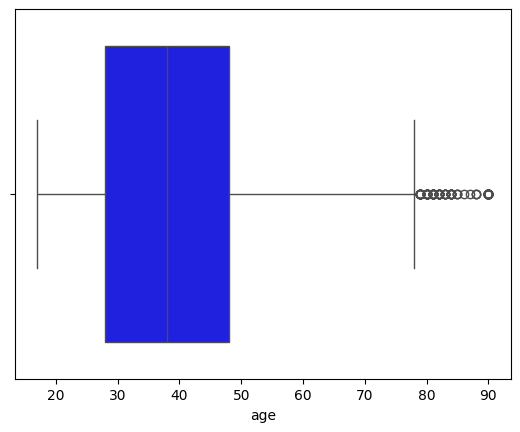

In [104]:
sns.boxplot(x='age', data=df_adult, color='blue')

<Axes: ylabel='hours_per_week'>

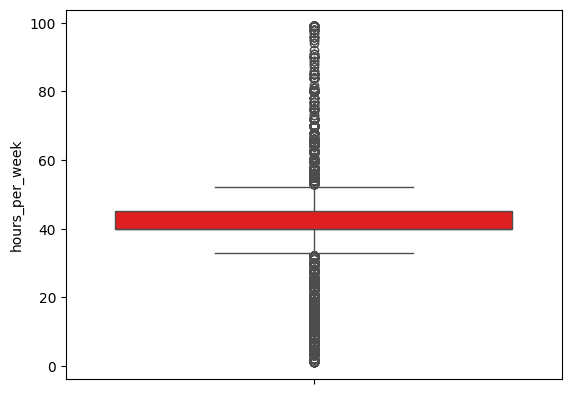

In [105]:
sns.boxplot(y='hours_per_week', data=df_adult, color='red')

### EJERCICIO 5.

Haz de nuevo el EJERCICIO 4, pero esta vez utilizando la librería SEABORN

Text(0, 0.5, 'frecuencia')

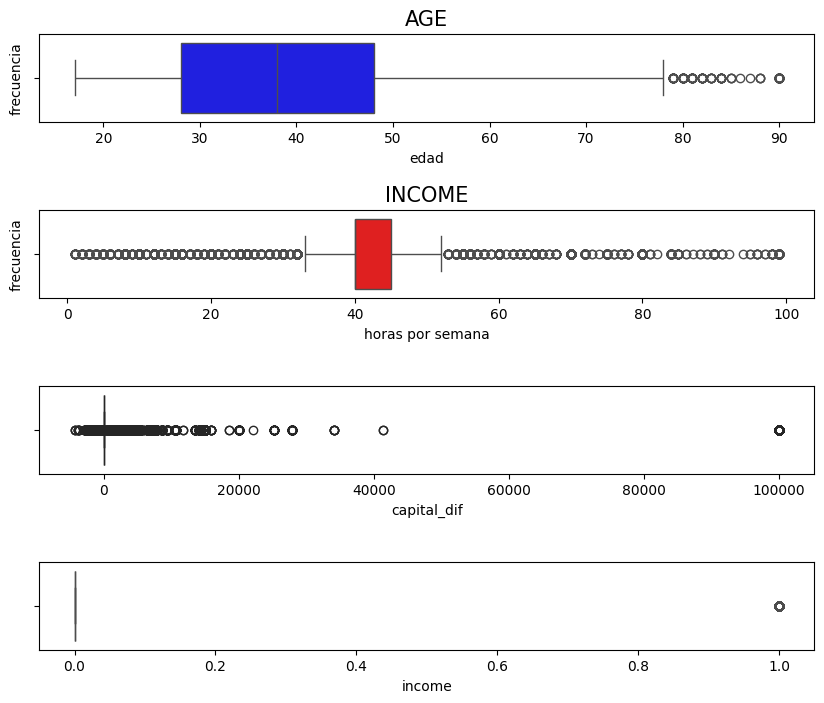

In [106]:
fig, mi_ax = plt.subplots(4,1,figsize=(10,8), gridspec_kw={'hspace': 1, 'wspace': 1})

sns.boxplot(x='age', data=df_adult, ax=mi_ax[0], color='blue')

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_xlabel('edad')
mi_ax[0].set_ylabel('frecuencia')

sns.boxplot(x='hours_per_week', data=df_adult, ax=mi_ax[1], color='red')

mi_ax[1].set_title('HOURS PER WEEK', fontsize=15)
mi_ax[1].set_xlabel('horas por semana')
mi_ax[1].set_ylabel('frecuencia')

sns.boxplot(x='capital_dif', data=df_adult, ax=mi_ax[2], color='green')

mi_ax[1].set_title('CAPITAL DIFFERENCE', fontsize=15)
mi_ax[1].set_xlabel('diferencia de capital')
mi_ax[1].set_ylabel('frecuencia')

sns.boxplot(x='income', data=df_adult, ax=mi_ax[3], color='yellow')

mi_ax[1].set_title('INCOME', fontsize=15)
mi_ax[1].set_xlabel('horas por semana')
mi_ax[1].set_ylabel('frecuencia')




### - Ultima vuelta de tuerca: BIDIMENSIONAL, estudio var. numérica según valores var. categórica, varias representaciones en la misma gráfica.

In [107]:
variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

In [108]:
variables_categoricas

['sex',
 'marital_status',
 'relationship',
 'race',
 'native_country',
 'education',
 'workclass',
 'occupation']

**- Grupos por género**

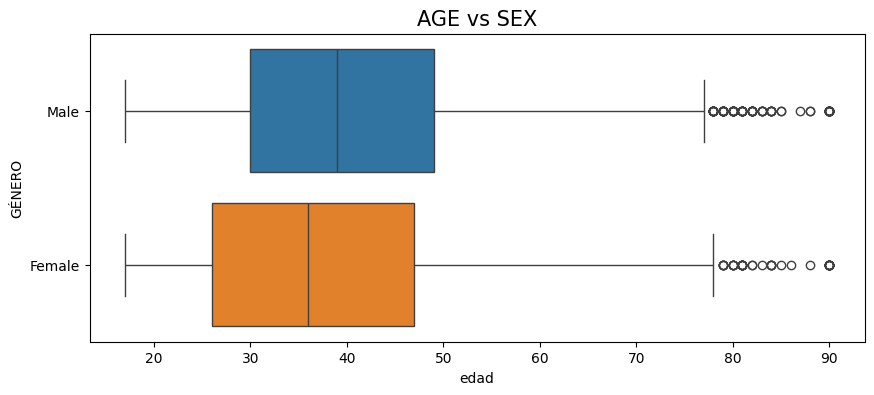

In [109]:
fig, mi_ax = plt.subplots(figsize=(10,4), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.boxplot(x='age', y='sex', hue='sex', data=df_adult, ax=mi_ax)

mi_ax.set_title('AGE vs SEX', fontsize=15)
mi_ax.set_xlabel('edad')
mi_ax.set_ylabel('GÉNERO');

### EJERCICIO 6.

Haz una gráfica similar a la anterior, esta vez con "hours_per_week" vs "sex".
¿Puedes sacar alguna conclusión o hipótesis?

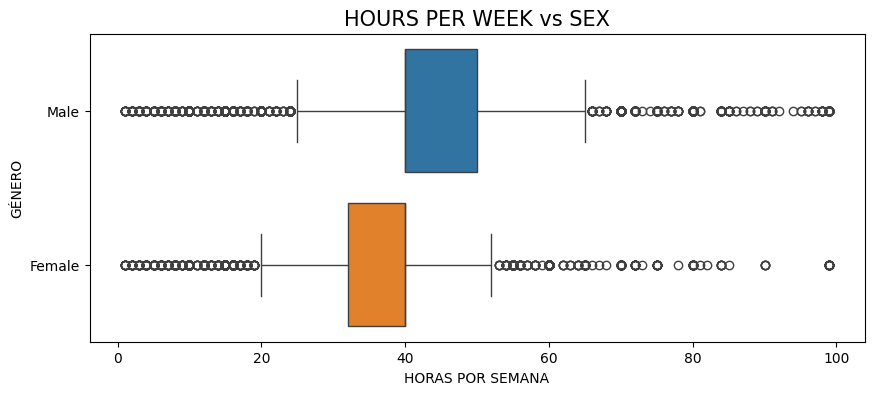

In [110]:
fig, mi_ax = plt.subplots(figsize=(10,4), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.boxplot(x='hours_per_week', y='sex', hue='sex', data=df_adult, ax=mi_ax)

mi_ax.set_title('HOURS PER WEEK vs SEX', fontsize=15)
mi_ax.set_xlabel('HORAS POR SEMANA')
mi_ax.set_ylabel('GÉNERO');

## CATEGÓRICAS: diagrama de barras

In [111]:
for categorica in variables_categoricas:

    print(f'Variable {categorica.upper()}:')
    print('Valores unicos: ')
    print(df_adult[categorica].unique(), end='\n'*2)
    print(df_adult[categorica].value_counts(), end='\n'*2)

Variable SEX:
Valores unicos: 
['Male' 'Female']

sex
Male      19246
Female     9850
Name: count, dtype: int64

Variable MARITAL_STATUS:
Valores unicos: 
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

marital_status
Married-civ-spouse       13249
Never-married             9173
Divorced                  4237
Separated                 1014
Widowed                    982
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

Variable RELATIONSHIP:
Valores unicos: 
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

relationship
Husband           11506
Not-in-family      7684
Own-child          4096
Unmarried          3317
Wife               1528
Other-relative      965
Name: count, dtype: int64

Variable RACE:
Valores unicos: 
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

race
White                 24438
Black                  3038
Asian

In [112]:
variables_categoricas

['sex',
 'marital_status',
 'relationship',
 'race',
 'native_country',
 'education',
 'workclass',
 'occupation']

**Nos centraremos en las  columnas ['sex', 'marital_status', 'relationship', 'race']**

### - Uso de "boxplot"

Echemos un vistazo a "value_counts()":

In [113]:
df_adult.marital_status.value_counts()


,count
marital_status,
Married-civ-spouse,13249
Never-married,9173
Divorced,4237
Separated,1014
Widowed,982
Married-spouse-absent,418
Married-AF-spouse,23


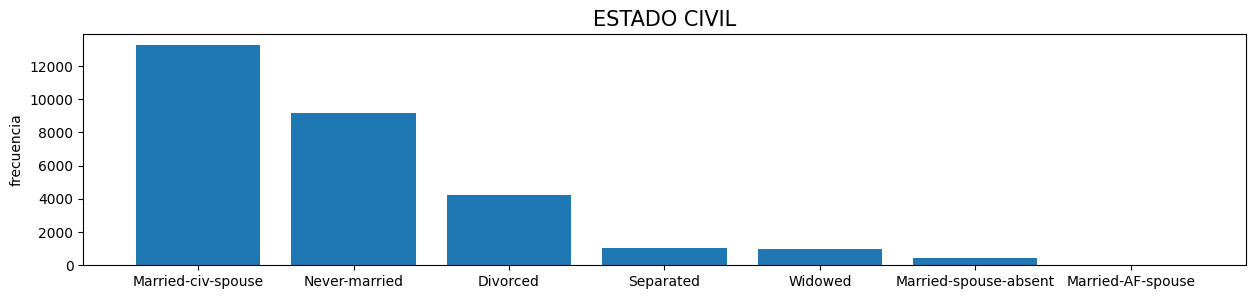

In [114]:
fig, mi_ax = plt.subplots(figsize=(15,3), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

valores_unicos = df_adult.marital_status.value_counts().index
conteo = df_adult.marital_status.value_counts().values

mi_ax.bar(x=valores_unicos, height=conteo)

mi_ax.set_title('ESTADO CIVIL', fontsize=15)
mi_ax.set_ylabel('frecuencia');


### - Uso de la librería "Seaborn"

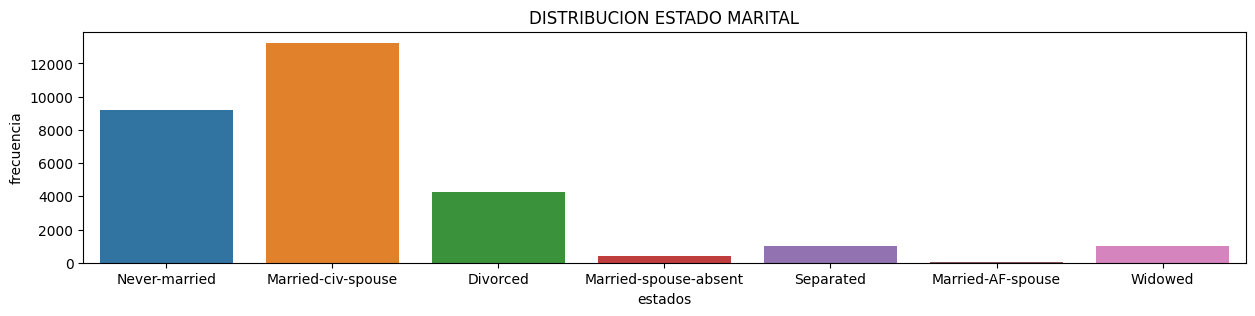

In [115]:
fig, mi_ax = plt.subplots(figsize=(15,3), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.countplot(x='marital_status', data=df_adult, hue='marital_status')

mi_ax.set_title('DISTRIBUCION ESTADO MARITAL')
mi_ax.set_xlabel('estados')
mi_ax.set_ylabel('frecuencia');

### EJERCICIO 7.

Haz el diagrama de barras para "race", "sex" y 'relationship' en una sola gráfica (recuerda "subplots" y ejes)


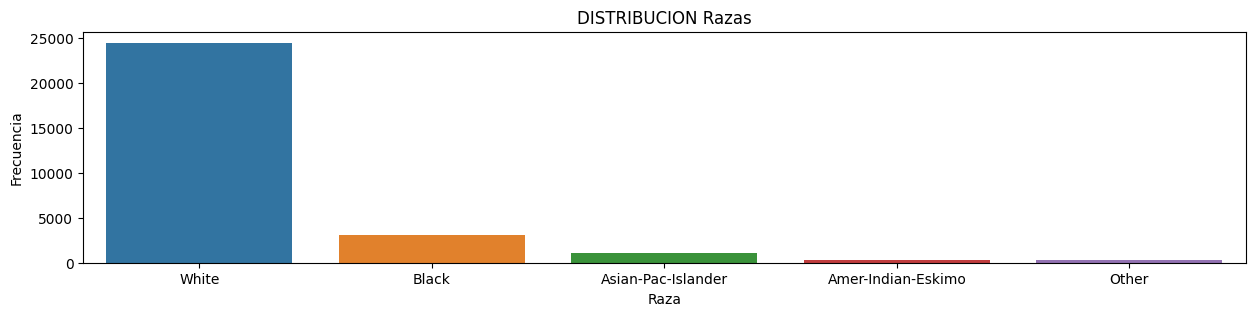

In [116]:
fig, mi_ax = plt.subplots(figsize=(15,3), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.countplot(x='race', data=df_adult, hue='race')

mi_ax.set_title('DISTRIBUCION Razas')
mi_ax.set_xlabel('Raza')
mi_ax.set_ylabel('Frecuencia');

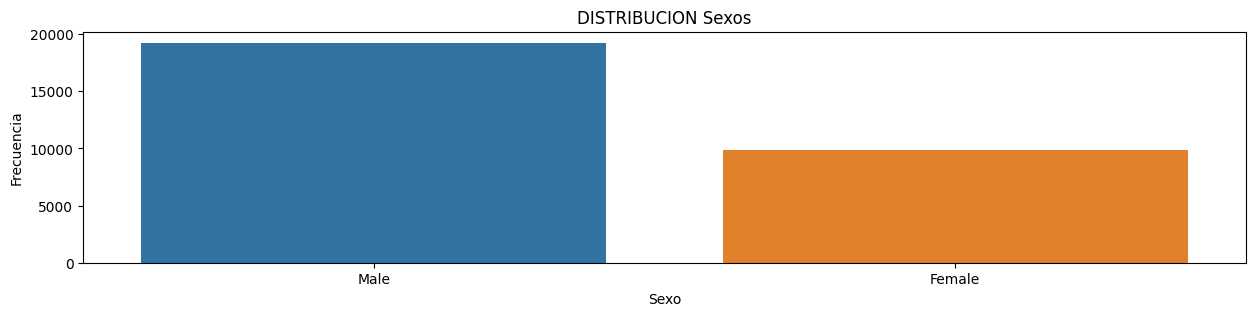

In [117]:
fig, mi_ax = plt.subplots(figsize=(15,3), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.countplot(x='sex', data=df_adult, hue='sex')

mi_ax.set_title('DISTRIBUCION Sexos')
mi_ax.set_xlabel('Sexo')
mi_ax.set_ylabel('Frecuencia');

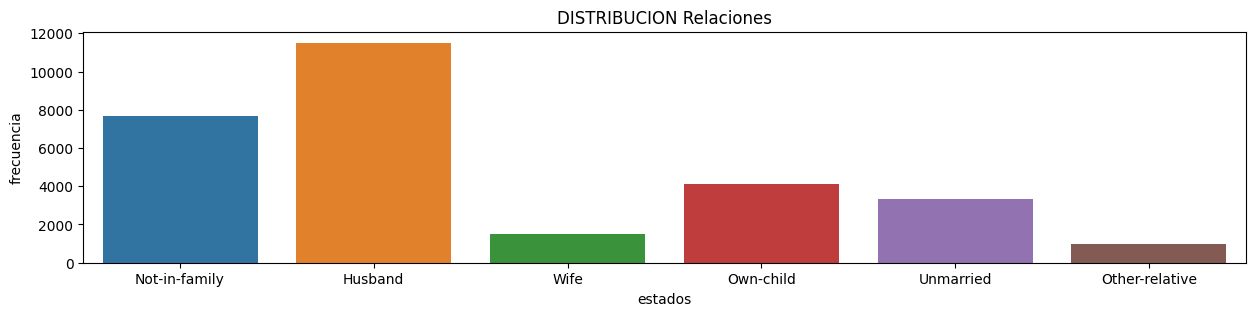

In [118]:
fig, mi_ax = plt.subplots(figsize=(15,3), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.countplot(x='relationship', data=df_adult, hue='relationship')

mi_ax.set_title('DISTRIBUCION Relaciones')
mi_ax.set_xlabel('estados')
mi_ax.set_ylabel('frecuencia');

# ANÁLISIS BIDIMENSIONAL

## DIAGRAMA DE PUNTOS: SCATTERPLOT

El diagrama de puntos nos sirve para ver la relación que hay entre dos variables numéricas continuas.

### - Uso de "scatter"

In [119]:
variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

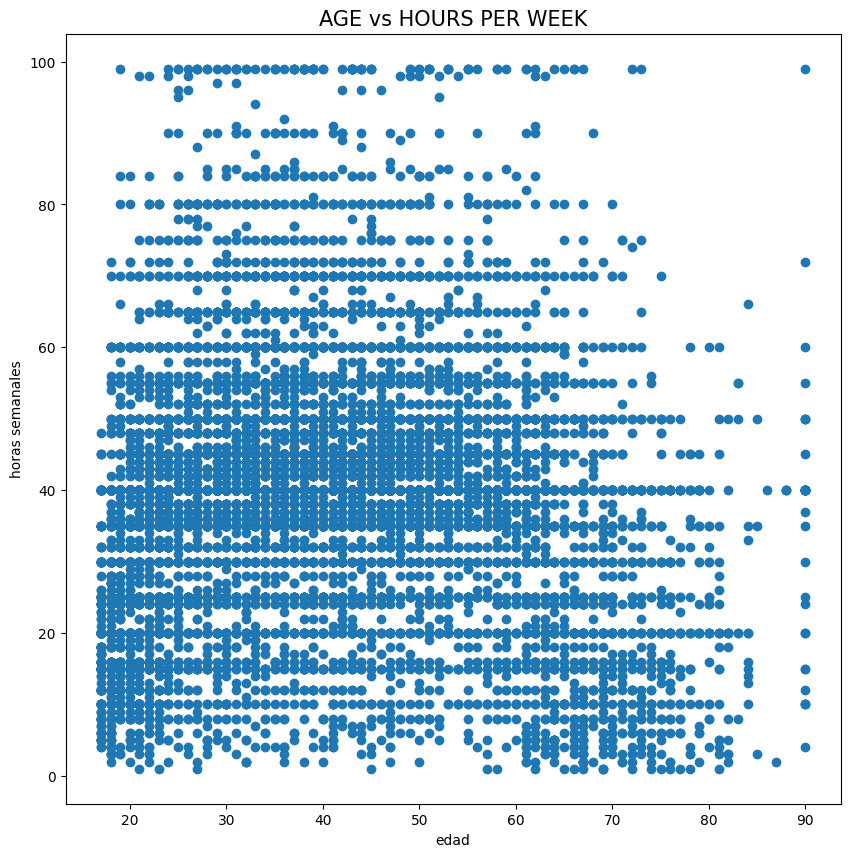

In [120]:
fig, mi_ax = plt.subplots(figsize=(10,10), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

mi_ax.scatter(x=df_adult.age, y=df_adult.hours_per_week)

mi_ax.set_title('AGE vs HOURS PER WEEK', fontsize=15)

mi_ax.set_xlabel('edad')
mi_ax.set_ylabel('horas semanales');


### - Uso de la librería "Seaborn"

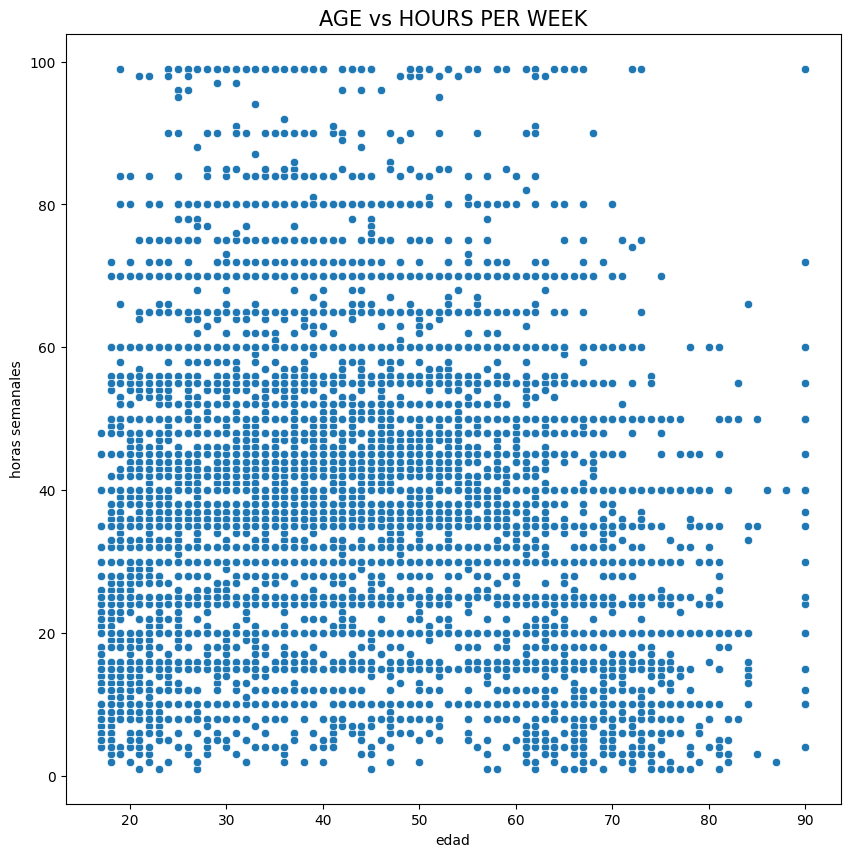

In [121]:
fig, mi_ax = plt.subplots(figsize=(10,10), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.scatterplot(x=df_adult.age, y=df_adult.hours_per_week)

mi_ax.set_title('AGE vs HOURS PER WEEK', fontsize=15)

mi_ax.set_xlabel('edad')
mi_ax.set_ylabel('horas semanales');

**En gráficas más complicadas (las veremos) la versión de Seaborn permite muchas mas opciones**

### - Uso de la librería "Seaborn": gráfica pairplot

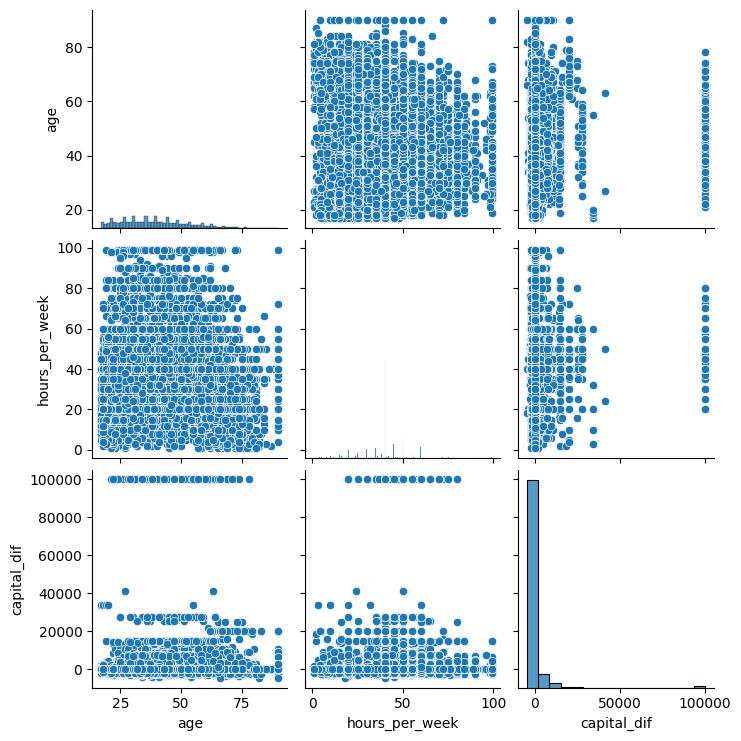

In [122]:
sns.pairplot(data=df_adult.drop(columns='income'), vars=['age', 'hours_per_week', 'capital_dif']);

### - Caso especial "regplot" de librería "Seaborn"

Dada la escasa relación de variables en nuestro caso, vamos a fabricarnos artificialmente dos variables, una con distibución uniforme y otra a partir de la original a la que sumamos un componente de "ruido", para que estén relacionadas.

In [123]:
x = np.random.uniform(10, 90, size=30)
y = x + np.random.normal(20, 15, size=len(x))

print('x: ', x)
print('y: ', y)

x:  [67.91691494 21.28385142 41.40979753 17.89216504 55.85784327 25.30979549
 57.10212496 88.24071709 32.80601468 24.50101007 83.32904533 39.4723992
 84.67407514 53.30762782 52.57382783 13.6434172  48.19444461 78.88221596
 13.41287162 51.70283119 82.52326541 77.99810642 36.11249837 62.3006342
 22.95835923 58.95138724 25.25434505 73.66339396 77.94000758 70.62487626]
y:  [ 69.78441604  34.13446574  67.1425302   42.41930945  63.57237354
  54.14836791  72.35785963  90.6258567   62.65527112  39.87956954
  79.13261351  50.05193636 114.13193631  53.79215604  72.02360457
  28.23955459  48.8034507   98.98956567  23.33364444  73.88662892
 114.753313    91.39619437  44.01378255  76.0482326   41.52592978
  75.52325993  32.71554856 103.62621216  78.37088606  90.21379233]


Vamos a la gráfica:

<Axes: >

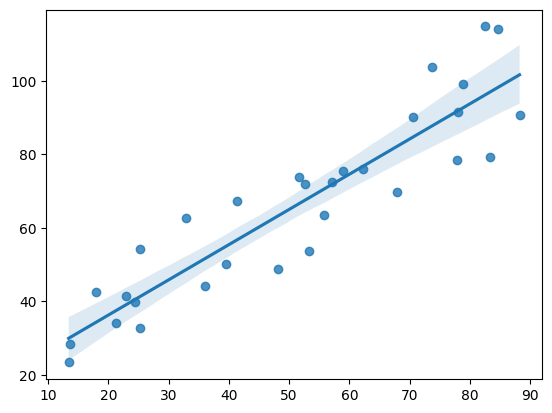

In [124]:
sns.regplot(x=x, y=y)

# MAPA DE CALOR (BIDIMENSIONAL y UNIDIMENSIONAL).

**Generalmente representa el mapa de contingencia de 2 variables**, sirviendo para casos como optimización de hiperparámetros, matriz de confusión (los veremos en la evaluación de resultados de modelos) **ó un caso de varias variables, la matriz de correlación.**

In [73]:
mat_corr = df_adult.corr()
mat_corr

ValueError: could not convert string to float: 'Male'

In [ ]:
c = plt.imshow(mat_corr, cmap='hot', interpolation='nearest')

plt.colorbar(c)

### - MEJOR OPCIÓN, librería "Seaborn", HEATMAP

In [ ]:
sns.heatmap(mat_corr, annot=True, cbar=True, cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.title('Correlación entre atributos')